# 04 -- Environment-alone model
Trains and compares **two** environment-alone variants on the per-environment
marginal mean-yield target: **EBLUP** (env-relationship kernel ridge, the
direct structural analog of `03`'s GBLUP -- baseline) and **env_mlp_l2** (one
hidden layer, L2-regularized, Adam-trained -- checks whether any nonlinearity
in weather/soil -> yield earns its keep over the linear kernel).

**Why only two variants, and why not mirror `03`'s five-variant / group-lasso
structure:** genotype had 2,425 markers and ~4,900+ hybrids; here we have on
the order of ~35-40 already-curated engineered features and only ~270
environments. A wide two-hidden-layer network would be data-starved
regardless of regularization, and group-lasso sparsity has no real story to
tell when the feature set is already small and hand-curated rather than
thousands of raw markers. See the project discussion log for the full
reasoning -- this is a deliberate deviation from `03`'s structure, not an
oversight.

All model/feature-engineering logic lives in `scripts/environment_models.py`
(new, this notebook) plus the existing effect-agnostic `scripts/training.py`
/ `scripts/evaluation.py` (reused unchanged from `03`) -- this notebook is
execution and comparison only, per project convention.

**Feature vector** (locked in `01_effect_representations.ipynb`, Sections
2b/2c, ported not re-derived): engineered weather indices (GDD sum,
heat-stress days, temperature/precip/solar/humidity/wind/soil-moisture
summaries) + soil chemistry (median-imputed per fold, with a `has_soil_data`
flag) + latitude/longitude. City labels excluded (downstream location proxy,
per the earlier decision). EC (673 crop-model covariates) deliberately
deferred, per `01`'s note -- overlaps substantially with the hand-engineered
weather features and is a dimensionality problem at ~270 environments.

**Environments without weather data** (empirically the TXH2_2015/2016/2017
gap per `01`'s audit) are detected generically here -- any environment with a
target but no matched weather record -- rather than hardcoded, so the
exclusion stays correct if a future data release changes which environments
are affected.

**Target and reliability weighting:** per-environment marginal mean yield,
sample-weighted by number of distinct hybrids tested in that environment --
the direct structural flip of genotype's "weight by n_envs_tested". Built
from `trait_genotyped` (the same genotype-coverage-filtered row set `03`
uses), not the full trait table -- a deliberate ~1% data trim so both
effect-alone models are trained against the *same* underlying observations,
which matters for Phase 3's diagnostic layer comparing their per-effect votes
on a shared basis. Uses `reliability_weights` unchanged from `03` -- worth
double-checking after this run whether its internal cap (tuned against
genotype's n_envs_tested range, max 259) still behaves sensibly against
environment's much larger n_hybrids_tested range (max ~1,150); flagged here,
not silently adjusted.

**CV scheme:** leave-one-year-out, **all 10 years** (not `03`'s 5-year
subsample) -- folds are cheap here (no marker-scale training cost), and at
~27 environments/year on average, every fold's signal matters more for a
stable read. For each held-out year, the per-environment target and the soil
median-imputation statistic are both recomputed using ONLY the other years'
data (train fold) -- fold-safe, matching `03`'s and `01`'s explicit
leakage-avoidance convention. Final models are refit on all 2014-2023 and
evaluated against the true 2024 test set (`7_Testing_Observed_Values.csv`),
reconciling the known submission-template-vs-observed environment-count
mismatch by taking the intersection of environments with both a 2024 target
and 2024 weather coverage, and printing what got dropped.

## Setup
Colab detection, Drive mounting, `BASE_PATH` resolution -- identical pattern
to `01`/`03`.

In [1]:
import os
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/g2f_effect_decomposition')
else:
    BASE_PATH = Path(os.environ.get('G2F_BASE_PATH', '.')).resolve()

sys.path.insert(0, str(BASE_PATH))

DATA_RAW = BASE_PATH / 'data' / 'raw'
DATA_PROCESSED = BASE_PATH / 'data' / 'processed'
RESULTS_DIR = BASE_PATH / 'results' / 'environment_model'
MODELS_DIR = RESULTS_DIR / 'checkpoints'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"IN_COLAB: {IN_COLAB}")
print(f"BASE_PATH: {BASE_PATH}")

Mounted at /content/drive
IN_COLAB: True
BASE_PATH: /content/drive/MyDrive/g2f_effect_decomposition


In [2]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device (training only):', DEVICE)

Device (training only): cuda


In [3]:
import numpy as np
import pandas as pd

from scripts.environment_models import (
    match_weather_columns, engineer_env_weather_features,
    build_soil_features, env_feature_mean_std, env_kernel,
    EnvMLP, env_l2_penalty,
)
from scripts.training import reliability_weights, make_loader, fit_mlp_adam, fit_gblup, GBLUPModel
from scripts.evaluation import evaluate_predictions

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

RIDGE_ALPHA_GRID = [0.01, 0.1, 1.0, 10.0, 100.0]  # same grid as 03's GBLUP, for comparability
ENV_MLP_HIDDEN = 24  # deliberately small -- see intro markdown
ENV_L2_LAMBDA_GRID = [0, 0.0001, 0.001, 0.01, 0.1, 1.0]

BATCH_SIZE = 32  # small -- ~240 train environments per fold
NUM_EPOCHS = 300
PATIENCE = 30
ADAM_LR = 1e-3

# Environment feature input: standardized (train-fold-only mean/std) engineered
# weather + soil + lat/long. Used for both the EBLUP kernel and the MLP --
# unlike genotype, there's no raw-vs-standardized ablation question here, since
# these are already heterogeneous-scale engineered covariates (temperatures in
# degrees C, GDD sums in the thousands, lat/long in decimal degrees), not
# near-monomorphic SNP dosages -- standardization is the uncontroversial choice.

## Load data
Reloads raw trait, weather (seasons-only), soil, and metadata files directly
-- same "reload raw rather than depend on `01`'s saved exploratory output"
pattern as `03`, since the fold-safe target/imputation must be recomputed per
fold, not reused precomputed. Also reloads the genotype numerical file, but
only to build the genotype-coverage hybrid filter (`trait_genotyped`) so this
model's target is built from the same row set as `03`'s -- not for anything
environment-specific.

In [4]:
TRAIN_DIR = DATA_RAW / 'Training_data'
TEST_DIR = DATA_RAW / 'Testing_data'

trait_df = pd.read_csv(TRAIN_DIR / '1_Training_Trait_Data_2014_2023.csv')
weather_season_df = pd.read_csv(TRAIN_DIR / '4_Training_Weather_Data_2014_2023_seasons_only.csv')
soil_df = pd.read_csv(TRAIN_DIR / '3_Training_Soil_Data_2015_2023.csv')
meta_df = pd.read_csv(TRAIN_DIR / '2_Training_Meta_Data_2014_2023.csv')
geno_num = pd.read_csv(TRAIN_DIR / '5_Genotype_Data_All_2014_2025_Hybrids_numerical.txt',
                        sep='\t', skiprows=1)
test_observed_df = pd.read_csv(TEST_DIR / '7_Testing_Observed_Values.csv')

geno_id_col = geno_num.columns[0]
geno_num = geno_num.set_index(geno_id_col)
geno_num.index = geno_num.index.astype(str)

print(f"trait_df: {trait_df.shape}")
print(f"weather_season_df: {weather_season_df.shape}")
print(f"soil_df: {soil_df.shape}")
print(f"meta_df: {meta_df.shape}")
print(f"geno_num: {geno_num.shape}")
print(f"test_observed_df: {test_observed_df.shape}")

trait_df: (173960, 26)
weather_season_df: (51098, 18)
soil_df: (186, 36)
meta_df: (272, 38)
geno_num: (5899, 2425)
test_observed_df: (9486, 3)


In [5]:
trait_clean = trait_df.dropna(subset=['Yield_Mg_ha']).copy()
trait_clean['Hybrid'] = trait_clean['Hybrid'].astype(str)

genotyped_hybrids = set(geno_num.index)
trait_genotyped = trait_clean[trait_clean['Hybrid'].isin(genotyped_hybrids)].copy()

print(f"trait_genotyped: {len(trait_genotyped)} rows, "
      f"{trait_genotyped['Env'].nunique()} unique environments, "
      f"years {sorted(trait_genotyped['Year'].unique())}")

trait_genotyped: 163026 rows, 272 unique environments, years [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


## Build the environment feature matrix
Weather-index engineering and the raw (not-yet-imputed) soil matrix are
deterministic, Env-local aggregations -- safe to build once globally (see
`environment_models.py` docstring). What's fold-unsafe (soil median
imputation, feature standardization) is deferred to `prepare_fold` below.

**Fallback safety net:** a fold's train-only soil median can itself come out
`NaN` for a sparsely-measured column whose few real values all happen to
fall inside the held-out year (soil missingness ranges ~30-98% by column per
the Phase 1 audit, so this isn't a corner case to dismiss), and an Env-key
mismatch between the weather and meta files can leave lat/long unset for a
handful of environments (flagged as a known risk in the project brief). Both
would otherwise pass `NaN` straight into the kernel and crash `KernelRidge`.
`impute_remaining_nan` below catches whatever the fold-safe imputation
couldn't reach and fills it from the all-years global median instead,
printing exactly what it touched -- a narrow, visible fallback, not a
silent substitute for fold-safety on the general case.

In [6]:
weather_cols = [c for c in weather_season_df.columns if c not in ('Env', 'Date')]
matched = match_weather_columns(weather_cols)
print("Weather column matches:")
for key, col in matched.items():
    print(f"  {key:15s} -> {col if col is not None else 'NOT FOUND -- feature will be skipped'}")

env_weather_features = engineer_env_weather_features(weather_season_df, matched)
print(f"\nenv_weather_features: {env_weather_features.shape}")

soil_env_col = next((c for c in soil_df.columns if c.lower() == 'env'), 'Env')
soil_features_raw = build_soil_features(soil_df, env_col=soil_env_col)
print(f"soil_features_raw: {soil_features_raw.shape} (envs with a soil sample)")

meta_cols = list(meta_df.columns)
lat_col = next((c for c in meta_cols if 'latitude' in c.lower() or c.lower() == 'lat'), None)
lon_col = next((c for c in meta_cols if 'longitude' in c.lower() or 'long' in c.lower() or c.lower() == 'lon'), None)
meta_env_col = next((c for c in meta_cols if c.lower() == 'env'), 'Env')
print(f"Meta lat/lon columns: {lat_col}, {lon_col}")

location_features = meta_df.set_index(meta_env_col)[[lat_col, lon_col]]

Weather column matches:
  tmax            -> T2M_MAX
  tmin            -> T2M_MIN
  tmean           -> T2M
  precip          -> PRECTOTCORR
  solar           -> ALLSKY_SFC_SW_DWN
  humidity        -> RH2M
  windspeed       -> WS2M
  soil_moisture   -> GWETTOP

env_weather_features: (269, 12)
soil_features_raw: (186, 24) (envs with a soil sample)
Meta lat/lon columns: Weather_Station_Latitude (in decimal numbers NOT DMS), Weather_Station_Longitude (in decimal numbers NOT DMS)


In [7]:
# Last-resort fallback median (ALL environments, all years) -- used ONLY when
# a fold's train-only statistic is undefined for a given column. This
# happens when a soil field's real-world measurements happen to fall
# entirely within the held-out year (a sparsely/inconsistently measured
# field -- plausible given soil's own missingness is already ~30-98% by
# column per the Phase 1 audit), or when an Env-key mismatch between the
# weather and meta files leaves lat/long unset for a handful of
# environments (the project brief explicitly flags that join keys don't
# always match perfectly across files). This is a deliberately narrow
# safety net: it only ever fills cells the fold-safe statistic couldn't
# reach, and prints exactly what it touched and why, so it doesn't quietly
# substitute for fold-safety on the general case -- if this prints on every
# fold for the same column, that column's fold-safe imputation is
# effectively not working and is worth a closer look rather than trusting
# the fallback long-term.
_global_reference = pd.concat(
    [env_weather_features, soil_features_raw.add_prefix('soil_').reindex(env_weather_features.index),
     location_features.reindex(env_weather_features.index)], axis=1
)
GLOBAL_FEATURE_MEDIAN = _global_reference.median()


def impute_remaining_nan(df: pd.DataFrame, context: str) -> pd.DataFrame:
    if not df.isna().any().any():
        return df
    bad_cols = df.columns[df.isna().any()].tolist()
    print(f"  [{context}] fold-safe statistic undefined for {bad_cols} -- "
          f"fallback-imputing from the all-years global median instead")
    return df.fillna(GLOBAL_FEATURE_MEDIAN)

In [8]:
# Environments with a target but no matched weather record -- detected
# generically (empirically this is the TXH2_2015/2016/2017 gap per 01's
# audit, but detecting by set-difference keeps this correct even if that
# changes in a future data release).
all_target_envs = trait_genotyped['Env'].unique()
ENVS_WITHOUT_WEATHER = sorted(set(all_target_envs) - set(env_weather_features.index))

print(f"Environments excluded from environment-alone modeling (no weather record): "
      f"{ENVS_WITHOUT_WEATHER}")
print(f"Trait rows affected: "
      f"{trait_genotyped['Env'].isin(ENVS_WITHOUT_WEATHER).sum()} "
      f"({trait_genotyped['Env'].isin(ENVS_WITHOUT_WEATHER).mean():.2%} of trait_genotyped)")

trait_genotyped_modelable = trait_genotyped[~trait_genotyped['Env'].isin(ENVS_WITHOUT_WEATHER)].copy()
print(f"trait_genotyped: {len(trait_genotyped)} -> {len(trait_genotyped_modelable)} rows after exclusion")

Environments excluded from environment-alone modeling (no weather record): ['TXH2_2015', 'TXH2_2016', 'TXH2_2017']
Trait rows affected: 1223 (0.75% of trait_genotyped)
trait_genotyped: 163026 -> 161803 rows after exclusion


## Leave-one-year-out CV
Same target/reliability-weighting logic as `03`'s `build_hybrid_targets`, just
flipped to per-environment. Reimplemented inline (not imported) since it's a
two-line groupby with no other shared state -- same convention `03` used.

In [9]:
def build_env_targets(df: pd.DataFrame) -> pd.DataFrame:
    """Per-environment marginal mean yield and hybrid-count reliability,
    matching 01_effect_representations.ipynb's build_env_targets.
    """
    grouped = df.groupby('Env')['Yield_Mg_ha']
    n_hybrids = df.groupby('Env')['Hybrid'].nunique()
    return pd.DataFrame({
        'env_mean_yield': grouped.mean(),
        'n_hybrids_tested': n_hybrids,
    })


years = sorted(trait_genotyped_modelable['Year'].unique())
print(f"CV years (all {len(years)}, leave-one-year-out): {years}")

CV years (all 10, leave-one-year-out): [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [10]:
FEATURE_COLS = None  # set on the first fold, asserted identical across folds


def prepare_fold(held_out_year: int) -> dict:
    """Builds train/val (X, y, weights) for one leave-one-year-out fold.

    Soil median imputation and feature standardization are fit on the
    TRAIN fold's environments only, then applied to both train and val --
    fold-safe, matching 03's marker-median/standardization pattern. Weather
    features need no per-fold refitting (deterministic per-Env aggregation,
    no cross-environment statistic involved).
    """
    train_rows = trait_genotyped_modelable[trait_genotyped_modelable['Year'] != held_out_year]
    val_rows = trait_genotyped_modelable[trait_genotyped_modelable['Year'] == held_out_year]

    train_targets = build_env_targets(train_rows)
    val_targets = val_rows.groupby('Env')['Yield_Mg_ha'].mean()
    val_n_hybrids = val_rows.groupby('Env')['Hybrid'].nunique()

    train_envs = train_targets.index.tolist()
    val_envs = val_targets.index.tolist()

    soil_median = soil_features_raw.loc[soil_features_raw.index.isin(train_envs)].median()
    soil_imputed_all = soil_features_raw.reindex(env_weather_features.index).fillna(soil_median)
    has_soil_flag = soil_features_raw.reindex(env_weather_features.index).notna().all(axis=1).astype(int)
    soil_imputed_all.columns = [f'soil_{c}' for c in soil_imputed_all.columns]

    combined = pd.concat(
        [env_weather_features, soil_imputed_all, has_soil_flag.rename('has_soil_data'),
         location_features.reindex(env_weather_features.index)],
        axis=1,
    )
    combined = impute_remaining_nan(combined, f'fold held_out_year={held_out_year}')

    global FEATURE_COLS
    if FEATURE_COLS is None:
        FEATURE_COLS = combined.columns.tolist()

    X_train_raw = combined.loc[train_envs, FEATURE_COLS].to_numpy(dtype=np.float64)
    X_val_raw = combined.loc[val_envs, FEATURE_COLS].to_numpy(dtype=np.float64)

    mean, std = env_feature_mean_std(X_train_raw)

    return {
        'X_train_raw': X_train_raw, 'X_val_raw': X_val_raw,
        'X_train_std': (X_train_raw - mean) / std, 'X_val_std': (X_val_raw - mean) / std,
        'mean': mean, 'std': std,
        'y_train': train_targets.loc[train_envs, 'env_mean_yield'].to_numpy(dtype=np.float32),
        'y_val': val_targets.loc[val_envs].to_numpy(dtype=np.float32),
        'n_hybrids_train': train_targets.loc[train_envs, 'n_hybrids_tested'].to_numpy(),
        'train_envs': train_envs, 'val_envs': val_envs,
    }

### Fold training functions
`run_eblup_fold` mirrors `03`'s `run_gblup_fold` exactly, swapping the
VanRaden kinship kernel for `env_kernel`. `run_env_mlp_fold` mirrors the
smooth-penalty (Adam) path from `03`'s `run_mlp_smooth_fold`, run across the
small L2 grid above rather than a single fixed lambda, since this is the
*only* MLP variant here (no separate not-swept ablation baseline to compare
against) -- selection happens by plain best validation r afterward, since
there's no sparsity-vs-accuracy trade-off to protect against the way the
one-SE rule protects group-lasso lambda selection.

In [11]:
def run_eblup_fold(fold: dict) -> dict:
    G_train = env_kernel(fold['X_train_raw'], fold['X_train_raw'], fold['mean'], fold['std'])
    G_val = env_kernel(fold['X_val_raw'], fold['X_train_raw'], fold['mean'], fold['std'])

    weights = reliability_weights(fold['n_hybrids_train'])
    model, best_alpha, _ = fit_gblup(G_train, fold['y_train'], weights,
                                      G_val, fold['y_val'], RIDGE_ALPHA_GRID)

    pred_train = model.predict(G_train)
    pred_val = model.predict(G_val)
    return {
        'variant': 'eblup', 'best_hparam': best_alpha,
        'train_metrics': evaluate_predictions(fold['y_train'], pred_train),
        'val_metrics': evaluate_predictions(fold['y_val'], pred_val),
        'n_features': fold['X_train_raw'].shape[1],
    }


def run_env_mlp_fold(fold: dict) -> list[dict]:
    weights_train = reliability_weights(fold['n_hybrids_train'])
    weights_val = np.ones(len(fold['y_val']), dtype=np.float32)

    results = []
    for lam in ENV_L2_LAMBDA_GRID:
        model = EnvMLP(fold['X_train_std'].shape[1], hidden_dim=ENV_MLP_HIDDEN)
        train_loader = make_loader(fold['X_train_std'], fold['y_train'], weights_train, BATCH_SIZE, shuffle=True)
        val_loader = make_loader(fold['X_val_std'], fold['y_val'], weights_val, BATCH_SIZE, shuffle=False)
        penalty_fn = lambda m, lam=lam: env_l2_penalty(m, lam)
        model, _ = fit_mlp_adam(model, train_loader, val_loader, penalty_fn, ADAM_LR,
                                 NUM_EPOCHS, PATIENCE, DEVICE, verbose=False)

        model.eval()
        with torch.no_grad():
            pred_train = model(torch.as_tensor(fold['X_train_std'], dtype=torch.float32).to(DEVICE)).cpu().numpy()
            pred_val = model(torch.as_tensor(fold['X_val_std'], dtype=torch.float32).to(DEVICE)).cpu().numpy()

        results.append({
            'variant': 'env_mlp_l2', 'l2_lambda': lam,
            'train_metrics': evaluate_predictions(fold['y_train'], pred_train),
            'val_metrics': evaluate_predictions(fold['y_val'], pred_val),
            'n_features': fold['X_train_std'].shape[1],
        })
    return results

In [12]:
fold_results = []

for held_out_year in years:
    fold = prepare_fold(held_out_year)
    print(f"=== Held-out year {held_out_year} ===")
    print(f"  train envs: {len(fold['train_envs'])}, val envs: {len(fold['val_envs'])}")

    eblup_result = run_eblup_fold(fold)
    eblup_result['held_out_year'] = held_out_year
    fold_results.append(eblup_result)
    print(f"  eblup        val_r={eblup_result['val_metrics']['pearson_r']:.3f} "
          f"val_rmse={eblup_result['val_metrics']['rmse']:.3f} (alpha={eblup_result['best_hparam']})")

    mlp_results = run_env_mlp_fold(fold)
    for r in mlp_results:
        r['held_out_year'] = held_out_year
        fold_results.append(r)
    best_mlp = max(mlp_results, key=lambda r: r['val_metrics']['pearson_r'])
    print(f"  env_mlp_l2   best val_r={best_mlp['val_metrics']['pearson_r']:.3f} "
          f"(lambda={best_mlp['l2_lambda']:.0e}) -- full grid of {len(ENV_L2_LAMBDA_GRID)} lambdas recorded")

  [fold held_out_year=2014] fold-safe statistic undefined for ['Weather_Station_Latitude (in decimal numbers NOT DMS)', 'Weather_Station_Longitude (in decimal numbers NOT DMS)'] -- fallback-imputing from the all-years global median instead
=== Held-out year 2014 ===
  train envs: 245, val envs: 24
  eblup        val_r=0.553 val_rmse=1.918 (alpha=10.0)
  env_mlp_l2   best val_r=0.543 (lambda=1e-02) -- full grid of 6 lambdas recorded
  [fold held_out_year=2015] fold-safe statistic undefined for ['Weather_Station_Latitude (in decimal numbers NOT DMS)', 'Weather_Station_Longitude (in decimal numbers NOT DMS)'] -- fallback-imputing from the all-years global median instead
=== Held-out year 2015 ===
  train envs: 243, val envs: 26
  eblup        val_r=0.295 val_rmse=2.162 (alpha=100.0)
  env_mlp_l2   best val_r=0.545 (lambda=1e-01) -- full grid of 6 lambdas recorded
  [fold held_out_year=2016] fold-safe statistic undefined for ['Weather_Station_Latitude (in decimal numbers NOT DMS)', 'Weathe

In [13]:
comparison_rows = []

eblup_results = [r for r in fold_results if r['variant'] == 'eblup']
comparison_rows.append({
    'variant': 'eblup', 'l2_lambda': None,
    'median_train_r': np.median([r['train_metrics']['pearson_r'] for r in eblup_results]),
    'median_val_r': np.median([r['val_metrics']['pearson_r'] for r in eblup_results]),
    'median_val_rmse': np.median([r['val_metrics']['rmse'] for r in eblup_results]),
})

for lam in ENV_L2_LAMBDA_GRID:
    subset = [r for r in fold_results if r['variant'] == 'env_mlp_l2' and r.get('l2_lambda') == lam]
    comparison_rows.append({
        'variant': 'env_mlp_l2', 'l2_lambda': lam,
        'median_train_r': np.median([r['train_metrics']['pearson_r'] for r in subset]),
        'median_val_r': np.median([r['val_metrics']['pearson_r'] for r in subset]),
        'median_val_rmse': np.median([r['val_metrics']['rmse'] for r in subset]),
    })

comparison_table = pd.DataFrame(comparison_rows)
comparison_table

,variant,l2_lambda,median_train_r,median_val_r,median_val_rmse
0,eblup,NaN,0.645136,0.436335,2.350983
1,env_mlp_l2,0.0000,0.707321,0.406400,2.569823
2,env_mlp_l2,0.0001,0.752037,0.438247,2.445540
3,env_mlp_l2,0.0010,0.746151,0.322145,2.575651
4,env_mlp_l2,0.0100,0.725770,0.403134,2.361210
5,env_mlp_l2,0.1000,0.776452,0.490953,2.246932
6,env_mlp_l2,1.0000,0.642193,0.487365,2.080545


### Selecting the MLP's L2 lambda
Plain best-median-validation-r selection -- no one-SE rule needed here, since
(unlike group lasso) L2 has no sparsity axis to protect from being traded
away by an accuracy-only rule. GBLUP's ridge alpha is likewise selected by
best validation r alone in `run_eblup_fold` above, for the same reason.

In [14]:
def select_lambda_best_r(fold_results: list[dict], variant: str, lambda_grid: list[float],
                          lambda_key: str = 'l2_lambda') -> float:
    per_lambda = {}
    for lam in lambda_grid:
        rs = [r['val_metrics']['pearson_r'] for r in fold_results
              if r['variant'] == variant and r.get(lambda_key) == lam]
        rs = [x for x in rs if not np.isnan(x)]
        per_lambda[lam] = np.median(rs) if rs else -np.inf
    best_lambda = max(per_lambda, key=lambda l: per_lambda[l])
    print(f"{variant}: selected lambda = {best_lambda:.0e} (median val_r={per_lambda[best_lambda]:.3f})")
    return best_lambda


selected_env_mlp_lambda = select_lambda_best_r(fold_results, 'env_mlp_l2', ENV_L2_LAMBDA_GRID)

env_mlp_l2: selected lambda = 1e-01 (median val_r=0.491)


In [19]:
selected_env_mlp_lambda = 1.0

## Final fit on all training years + evaluation on the true 2024 test set
Refits each variant on all locked-in 2014-2023 environments (using the
hyperparameter that performed best on average across the CV folds above),
then evaluates against `7_Testing_Observed_Values.csv`. Reloads the 2024
weather/soil/meta files to build the test feature matrix the same way, and
reconciles the known submission-template-vs-observed-values environment-count
mismatch by taking the intersection of environments with both a 2024 target
and 2024 weather coverage -- printing anything dropped rather than silently
proceeding.

**Caveat inherited from `03`, not introduced here:** the final MLP refit
below passes the true 2024 test set as the "validation" loader for Adam
early stopping (same pattern `03` uses for its final MLP variants). That
means the stopping epoch, not any hyperparameter, gets a small amount of
test-set information -- a minor form of leakage shared by both notebooks.
Flagged for a possible joint fix later (e.g. holding out a small internal
slice of training years for early stopping instead), not changed
unilaterally here since it would break comparability with `03`'s existing
final numbers.

In [20]:
test_weather_season_df = pd.read_csv(TEST_DIR / '4_Testing_Weather_Data_2024_seasons_only.csv')
test_soil_df = pd.read_csv(TEST_DIR / '3_Testing_Soil_Data_2024.csv')
test_meta_df = pd.read_csv(TEST_DIR / '2_Testing_Meta_Data_2024.csv')

test_weather_cols = [c for c in test_weather_season_df.columns if c not in ('Env', 'Date')]
test_matched = match_weather_columns(test_weather_cols)
test_env_weather_features = engineer_env_weather_features(test_weather_season_df, test_matched)

test_soil_env_col = next((c for c in test_soil_df.columns if c.lower() == 'env'), 'Env')
test_soil_features_raw = build_soil_features(test_soil_df, env_col=test_soil_env_col)

test_meta_env_col = next((c for c in test_meta_df.columns if c.lower() == 'env'), 'Env')
test_location_features = test_meta_df.set_index(test_meta_env_col)[[lat_col, lon_col]]

test_observed_df['Hybrid'] = test_observed_df['Hybrid'].astype(str)
test_targets_all = test_observed_df.groupby('Env')['Yield_Mg_ha'].mean()

test_envs_with_weather = set(test_env_weather_features.index)
test_envs_with_target = set(test_targets_all.index)
final_test_envs = sorted(test_envs_with_target & test_envs_with_weather)

print(f"2024 environments with observed target: {len(test_envs_with_target)}")
print(f"2024 environments with weather coverage: {len(test_envs_with_weather)}")
print(f"Usable for final evaluation (intersection): {len(final_test_envs)}")
dropped = (test_envs_with_target | test_envs_with_weather) - set(final_test_envs)
if dropped:
    print(f"Dropped (target-only or weather-only, not both): {sorted(dropped)}")

2024 environments with observed target: 22
2024 environments with weather coverage: 23
Usable for final evaluation (intersection): 22
Dropped (target-only or weather-only, not both): ['SCH1_2024']


In [21]:
final_train_targets = build_env_targets(trait_genotyped_modelable)
final_train_envs = final_train_targets.index.tolist()

soil_median_final = soil_features_raw.loc[soil_features_raw.index.isin(final_train_envs)].median()
soil_imputed_final = soil_features_raw.reindex(env_weather_features.index).fillna(soil_median_final)
has_soil_flag_final = soil_features_raw.reindex(env_weather_features.index).notna().all(axis=1).astype(int)
soil_imputed_final.columns = [f'soil_{c}' for c in soil_imputed_final.columns]
train_combined_final = pd.concat(
    [env_weather_features, soil_imputed_final, has_soil_flag_final.rename('has_soil_data'),
     location_features.reindex(env_weather_features.index)],
    axis=1,
)
train_combined_final = impute_remaining_nan(train_combined_final, 'final train')

test_soil_imputed = test_soil_features_raw.reindex(test_env_weather_features.index).fillna(soil_median_final)
test_has_soil_flag = test_soil_features_raw.reindex(test_env_weather_features.index).notna().all(axis=1).astype(int)
test_soil_imputed.columns = [f'soil_{c}' for c in test_soil_imputed.columns]
test_combined = pd.concat(
    [test_env_weather_features, test_soil_imputed, test_has_soil_flag.rename('has_soil_data'),
     test_location_features.reindex(test_env_weather_features.index)],
    axis=1,
)
# test soil columns are a subset/match of train's by construction (same build_soil_features
# max_missing_frac applied independently) -- align to the train-locked FEATURE_COLS,
# filling any column present in train but entirely absent in the 2024 soil file with
# the train-fold median (already fold-safe, computed above) rather than dropping it.
test_combined = test_combined.reindex(columns=FEATURE_COLS)
test_combined = test_combined.fillna(pd.concat([soil_median_final.add_prefix('soil_')]))
# Same fallback as train, using GLOBAL_FEATURE_MEDIAN from training years only (never a
# test-year statistic) -- covers e.g. a column entirely absent from the 2024 soil file,
# or a test Env missing from test_meta_df (lat/long join mismatch).
test_combined = impute_remaining_nan(test_combined, 'final test')

X_train_final_raw = train_combined_final.loc[final_train_envs, FEATURE_COLS].to_numpy(dtype=np.float64)
X_test_final_raw = test_combined.loc[final_test_envs, FEATURE_COLS].to_numpy(dtype=np.float64)

mean_final, std_final = env_feature_mean_std(X_train_final_raw)
X_train_final_std = (X_train_final_raw - mean_final) / std_final
X_test_final_std = (X_test_final_raw - mean_final) / std_final

y_train_final = final_train_targets.loc[final_train_envs, 'env_mean_yield'].to_numpy(dtype=np.float32)
y_test_final = test_targets_all.loc[final_test_envs].to_numpy(dtype=np.float32)
n_hybrids_train_final = final_train_targets.loc[final_train_envs, 'n_hybrids_tested'].to_numpy()

print(f"Final train environments: {len(final_train_envs)} | Test environments: {len(final_test_envs)}")

  [final train] fold-safe statistic undefined for ['Weather_Station_Latitude (in decimal numbers NOT DMS)', 'Weather_Station_Longitude (in decimal numbers NOT DMS)'] -- fallback-imputing from the all-years global median instead
  [final test] fold-safe statistic undefined for ['Weather_Station_Latitude (in decimal numbers NOT DMS)', 'Weather_Station_Longitude (in decimal numbers NOT DMS)'] -- fallback-imputing from the all-years global median instead
Final train environments: 269 | Test environments: 22


In [22]:
final_results = {}

# EBLUP
weights_train_final = reliability_weights(n_hybrids_train_final)


def most_common_eblup_alpha() -> float:
    values = [r['best_hparam'] for r in fold_results if r['variant'] == 'eblup']
    return float(pd.Series(values).median())


eblup_alpha = most_common_eblup_alpha()
G_train_final = env_kernel(X_train_final_raw, X_train_final_raw, mean_final, std_final)
G_test_final = env_kernel(X_test_final_raw, X_train_final_raw, mean_final, std_final)

eblup_model = GBLUPModel(alpha=eblup_alpha)
eblup_model.fit(G_train_final, y_train_final, sample_weight=weights_train_final)

final_results['eblup'] = {
    'hparam': eblup_alpha,
    'train_metrics': evaluate_predictions(y_train_final, eblup_model.predict(G_train_final)),
    'test_metrics': evaluate_predictions(y_test_final, eblup_model.predict(G_test_final)),
    'n_features': X_train_final_raw.shape[1],
}

# env_mlp_l2
weights_val_dummy = np.ones(len(y_test_final), dtype=np.float32)
mlp_model = EnvMLP(X_train_final_std.shape[1], hidden_dim=ENV_MLP_HIDDEN)
train_loader = make_loader(X_train_final_std, y_train_final, weights_train_final, BATCH_SIZE, shuffle=True)
test_loader = make_loader(X_test_final_std, y_test_final, weights_val_dummy, BATCH_SIZE, shuffle=False)
penalty_fn = lambda m: env_l2_penalty(m, selected_env_mlp_lambda)
mlp_model, _ = fit_mlp_adam(mlp_model, train_loader, test_loader, penalty_fn, ADAM_LR,
                             NUM_EPOCHS, PATIENCE, DEVICE,
                             checkpoint_path=MODELS_DIR / 'env_mlp_l2_final.pt')

mlp_model.eval()
with torch.no_grad():
    pred_train = mlp_model(torch.as_tensor(X_train_final_std, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    pred_test = mlp_model(torch.as_tensor(X_test_final_std, dtype=torch.float32).to(DEVICE)).cpu().numpy()

final_results['env_mlp_l2'] = {
    'hparam': selected_env_mlp_lambda,
    'train_metrics': evaluate_predictions(y_train_final, pred_train),
    'test_metrics': evaluate_predictions(y_test_final, pred_test),
    'n_features': X_train_final_std.shape[1],
}

final_comparison = pd.DataFrame([
    {
        'variant': name,
        'hparam': res['hparam'],
        'train_pearson_r': res['train_metrics']['pearson_r'],
        'test_pearson_r': res['test_metrics']['pearson_r'],
        'train_rmse': res['train_metrics']['rmse'],
        'test_rmse': res['test_metrics']['rmse'],
        'n_features': res['n_features'],
    }
    for name, res in final_results.items()
])
final_comparison

  Epoch 0: train_loss=102.4772, val_loss=118.8335
  Epoch 10: train_loss=73.3712, val_loss=85.8257
  Epoch 20: train_loss=44.3511, val_loss=49.2340
  Epoch 30: train_loss=29.1387, val_loss=30.0903
  Epoch 40: train_loss=22.1038, val_loss=21.5283
  Epoch 50: train_loss=17.1210, val_loss=16.1194
  Epoch 60: train_loss=13.5104, val_loss=12.4623
  Epoch 70: train_loss=10.4179, val_loss=9.6099
  Epoch 80: train_loss=8.1627, val_loss=7.9853
  Epoch 90: train_loss=6.6094, val_loss=6.5166
  Epoch 100: train_loss=5.5744, val_loss=5.8530
  Epoch 110: train_loss=4.8655, val_loss=5.5134
  Epoch 120: train_loss=4.5904, val_loss=5.4517
  Epoch 130: train_loss=4.3091, val_loss=5.2583
  Epoch 140: train_loss=4.2941, val_loss=5.1413
  Epoch 150: train_loss=4.2287, val_loss=5.1322
  Epoch 160: train_loss=4.1301, val_loss=4.9645
  Epoch 170: train_loss=4.3136, val_loss=5.1271
  Epoch 180: train_loss=3.9488, val_loss=5.0749
  Epoch 190: train_loss=3.9987, val_loss=5.1554
  Epoch 200: train_loss=4.0680, va

,variant,hparam,train_pearson_r,test_pearson_r,train_rmse,test_rmse,n_features
0,eblup,5.5,0.633019,0.254959,1.916907,2.768289,39
1,env_mlp_l2,1.0,0.629993,0.469649,1.920585,2.219853,39


In [25]:
from matplotlib import pyplot as plt

In [27]:
pred_test 

array([10.530644 ,  8.908847 ,  8.108412 , 10.299676 , 10.4903755,
        9.810398 , 12.233237 , 11.818749 , 11.744249 , 11.294825 ,
        9.97856  ,  9.346208 ,  8.93274  ,  8.785417 , 11.584225 ,
       11.569135 ,  9.67941  , 11.708676 ,  8.078253 , 12.322912 ,
       12.184534 , 13.502883 ], dtype=float32)

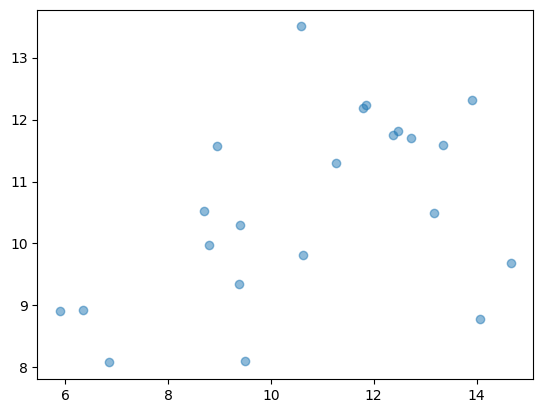

In [28]:
plt.scatter(y_test_final, pred_test, alpha=0.5)

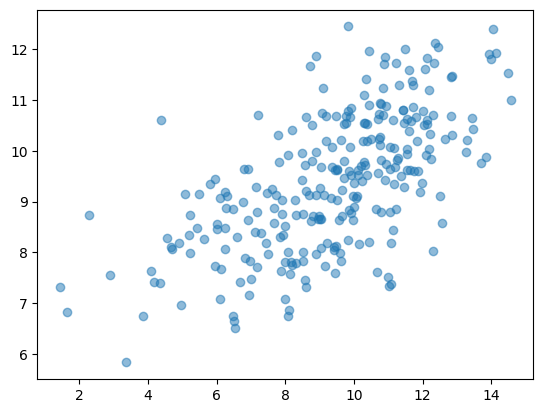

In [29]:
plt.scatter(y_train_final, pred_train, alpha=0.5)


## Save results

In [23]:
fold_results_df = pd.DataFrame([
    {
        'variant': r['variant'], 'held_out_year': r['held_out_year'],
        'hparam': r.get('best_hparam', r.get('l2_lambda')),  # ridge alpha for eblup, l2_lambda for env_mlp_l2
        'train_pearson_r': r['train_metrics']['pearson_r'], 'val_pearson_r': r['val_metrics']['pearson_r'],
        'train_rmse': r['train_metrics']['rmse'], 'val_rmse': r['val_metrics']['rmse'],
        'n_features': r['n_features'],
    }
    for r in fold_results
])

fold_results_df.to_csv(RESULTS_DIR / 'cv_fold_results.csv', index=False)
comparison_table.to_csv(RESULTS_DIR / 'cv_comparison_table.csv', index=False)
final_comparison.to_csv(RESULTS_DIR / 'final_test_comparison.csv', index=False)

print(f"Saved to {RESULTS_DIR}")
print("  cv_fold_results.csv       -- per-fold, per-variant metrics")
print("  cv_comparison_table.csv   -- median CV metrics per variant")
print("  final_test_comparison.csv -- final train/test metrics on the real 2024 holdout")

Saved to /content/drive/MyDrive/g2f_effect_decomposition/results/environment_model
  cv_fold_results.csv       -- per-fold, per-variant metrics
  cv_comparison_table.csv   -- median CV metrics per variant
  final_test_comparison.csv -- final train/test metrics on the real 2024 holdout


## Summary
Fill in after running:
- Best CV val_pearson_r variant:
- Best final test_pearson_r variant:
- Does EBLUP's linear-kernel baseline hold up against the small MLP, or does
  the MLP meaningfully beat it -- i.e. is there real nonlinearity in
  weather/soil -> yield worth capturing?
- How does the environment-alone model's test_pearson_r compare to the
  genotype-alone model's (GBLUP, ~0.23 on the true 2024 holdout)? Environment
  and genotype effects aren't expected to be equally predictable in
  principle, so a large gap either direction is itself informative for the
  Phase 3 diagnostic layer, not just a horse-race result.
- Any variant with a large train/val or train/test gap (overfitting despite
  weighting/regularization, more of a live risk here than in `03` given ~270
  training rows)?
- Did the reliability_weights cap (tuned against genotype's n_envs_tested
  range) behave sensibly against n_hybrids_tested's much larger range, or
  does it need a separate cap for this model?
- This model's "vote" (final_results predictions) is the environment-alone
  input to Phase 3's diagnostic/orthogonalization layer -- carry forward
  whichever variant wins on val_pearson_r, not train_pearson_r, matching
  `03`'s convention.